# Assignment 1 – MNIST Digit Recognition


## Problem Statement




Build your first handwritten digit classifier using the MNIST dataset and Logistic Regression from scikit-learn. Report training accuracy, test accuracy, and visualize five correct and five incorrect predictions.






In [18]:
#import the required libs

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [15]:
# Load MNIST dataset
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [16]:
print("Data Shape :", mnist.data.shape)
print("Target Shape:", mnist.target.shape)

Data Shape : (70000, 784)
Target Shape: (70000,)


In [19]:
print("Digits:", np.unique(mnist.target))

Digits: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


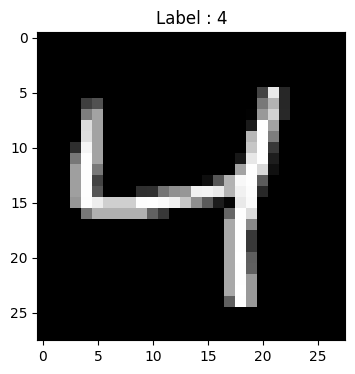

In [27]:
plt.figure(figsize=(4,4))

plt.imshow(
    mnist.data[2].reshape(28,28),
    cmap="gray"
)
plt.title(f"Label : {mnist.target[2]}")
plt.show()

In [28]:
# Features (pixel values)
X = mnist.data

# Target (digit labels)
y = mnist.target.astype(int)

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (70000, 784)
Target Shape  : (70000,)


In [29]:
#Split the Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 56000
Testing Samples  : 14000


In [30]:
#Normalize the Pixel Values

X_train = X_train / 255.0
X_test = X_test / 255.0


In [31]:
#Train the Logistic Regression Model


# Create the Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [32]:
# Predict the training and testing data

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [33]:
# Training Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

# Testing Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

Training Accuracy : 0.9390
Testing Accuracy  : 0.9202


In [34]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



In [35]:
cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=range(10),
    columns=range(10)
)

cm_df

,0,1,2,3,4,5,6,7,8,9
0,1297,1,7,0,3,11,12,4,6,2
1,0,1548,6,10,3,12,0,4,15,2
2,5,20,1233,20,15,10,21,17,29,10
3,6,10,30,1281,1,39,7,18,23,18
4,5,3,6,5,1202,5,10,8,7,44
5,4,12,8,43,11,1119,22,4,36,14
6,5,5,19,1,14,17,1331,1,3,0
7,6,4,26,3,10,6,0,1416,1,31
8,10,27,14,44,6,42,9,9,1177,19
9,8,11,5,13,36,7,0,46,15,1279


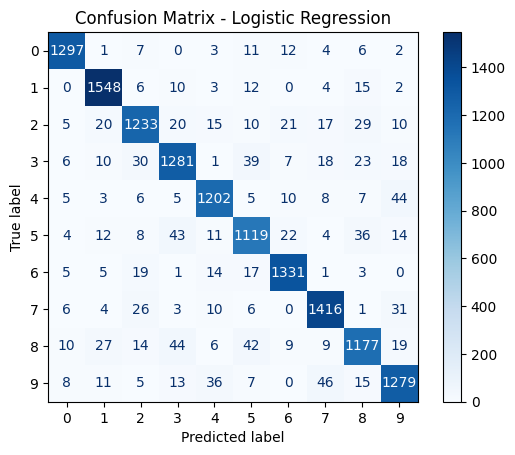

In [36]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

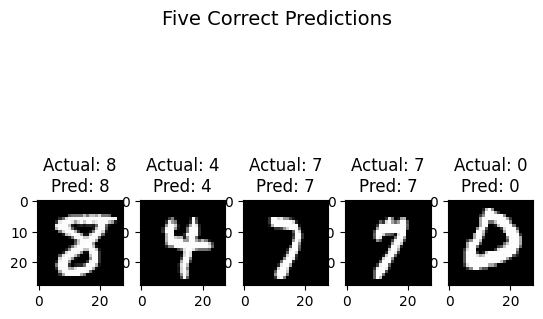

In [41]:
# Find correctly predicted images
correct_indices = np.where(y_test == y_test_pred)[0][:5]

# Plot the first five correct predictions
for i, idx in enumerate(correct_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {y_test[idx]}\nPred: {y_test_pred[idx]}")
plt.suptitle("Five Correct Predictions", fontsize=14)
plt.show()

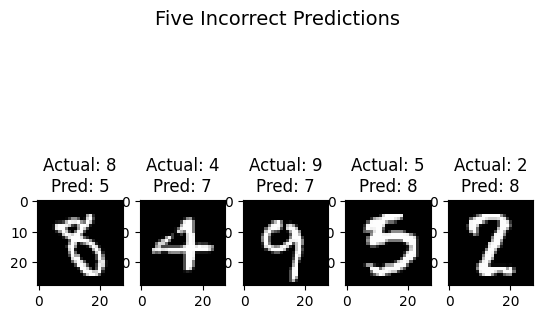

In [43]:
# Find incorrectly predicted images
incorrect_indices = np.where(y_test != y_test_pred)[0][:5]
# Plot the first five incorrect predictions

for i, idx in enumerate(incorrect_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {y_test[idx]}\nPred: {y_test_pred[idx]}")
plt.suptitle("Five Incorrect Predictions", fontsize=14)
plt.show()

## Observations

- The MNIST dataset containing 70,000 handwritten digit images was successfully loaded using `fetch_openml()`.
- The dataset consists of 784 input features (28 × 28 pixel values) and 10 output classes representing digits 0–9.
- The dataset was divided into training (56,000 images) and testing (14,000 images) sets using an 80:20 split.
- Pixel values were normalized to the range of 0–1 by dividing each pixel value by 255, which improved the convergence of the Logistic Regression model.
- The Logistic Regression classifier achieved a **training accuracy of 93.9%** and a **testing accuracy of 92.02%**, indicating good generalization on unseen handwritten digits.
- The classification report showed high precision, recall, and F1-score across most digit classes.
- The confusion matrix contained strong diagonal values, indicating that the majority of handwritten digits were classified correctly.
- The visualization of five correct and five incorrect predictions helped identify the model's strengths and the handwritten digits that were more difficult to classify.